# 05. Explicabilidade do Modelo de Churn (SHAP)

## Pergunta de negocio

O modelo de churn alimenta a lista de clientes que o time de retencao vai acionar. Duas areas
precisam de explicacao, nao so de score:

- **Time de retencao:** por que *este* cliente entrou na lista? (justificar a acao)
- **Time de risco / governanca:** o modelo se apoia em sinal de comportamento real, ou em algo
  que nao deveria estar ali (vazamento, artefato de dado)?

`feature_importances_` (gain), no notebook 02, responde so "o que o modelo usa no geral". SHAP
responde os dois niveis: **global** (o que dirige o modelo) e **local** (por que um cliente
especifico recebeu aquele score).

## Entregaveis

1. Importancia global via SHAP: `beeswarm` e `bar`
2. Check de consistencia: ranking SHAP contra ranking gain do notebook 02
3. Sanidade de dominio: direcao de cada top feature faz sentido para churn?
4. Explicacao individual: `waterfall` de 3 clientes (score alto, baixo, na fronteira 0.20)
5. Conclusao da Evaluation: o modelo passa no check de explicabilidade?

Figuras salvas em `reports/figures/` com prefixo `shap_`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import joblib
from scipy.stats import spearmanr

ROOT = next(
    p for p in [Path().resolve(), Path().resolve().parent, Path().resolve().parent.parent]
    if (p / 'src').exists()
)
PROCESSED_DIR = ROOT / 'data' / 'processed'
MODEL_DIR = ROOT / 'models' / 'churn'
FIGURES_DIR = ROOT / 'reports' / 'figures'

model = joblib.load(MODEL_DIR / 'xgb_churn_calibrated.pkl')
X_train = pd.read_parquet(PROCESSED_DIR / 'X_train.parquet')
X_test = pd.read_parquet(PROCESSED_DIR / 'X_test.parquet')
y_test = pd.read_parquet(PROCESSED_DIR / 'y_test.parquet').squeeze()
churn_scores = pd.read_parquet(PROCESSED_DIR / 'churn_scores.parquet')

FEATURES = list(X_test.columns)
print(f'modelo: {type(model).__name__} | folds calibrados: {len(model.calibrated_classifiers_)}')
print(f'X_test: {X_test.shape} | churn rate teste: {y_test.mean():.1%}')

modelo: CalibratedClassifierCV | folds calibrados: 5
X_test: (552, 21) | churn rate teste: 20.3%


## 1. Abordagem: SHAP num modelo calibrado

O modelo em producao e um `CalibratedClassifierCV(XGBoost, cv=5, method='sigmoid')`: a predicao
final e a **media de 5 probabilidades calibradas**, uma por fold. Isso levanta dois pontos.

**1. `TreeExplainer` precisa de uma arvore unica.** TreeSHAP foi calculado de cada um dos 5
estimadores-base (XGBoost) e foi tirado a **media dos valores SHAP**. Isso aproxima a contribuicao
media entre as folds, o modelo real faz a media de 5 *probabilidades calibradas*, enquanto aqui 
soma-se SHAP em espaco de *margem* dos estimadores-base. Para importancia global e direcao do 
efeito, essa aproximacao e a pratica padrao. 

**2. SHAP explica a margem (log-odds) do XGBoost, nao a probabilidade calibrada.** Dentro de
*uma* fold, a calibracao `sigmoid` so faz o valor subir, entao uma feature que empurra a margem 
para cima empurra a probabilidade calibrada para cima: sinal e ranking de contribuicao se mantem. 
Ao agregar as 5 folds essa correspondencia deixa de ser exata, mas o sentido geral se preserva. 
Na leitura individual (`waterfall`), a soma das contribuicoes da a **margem**, nao o `P(churn)` 
calibrado mostrado ao negocio: escalas diferentes, mesma direcao.

**TreeSHAP nativo do XGBoost** (`booster.predict(pred_contribs=True)`), que e o mesmo
algoritmo exato da lib `shap` porem calculado pelo proprio XGBoost.

In [2]:
# TreeSHAP nativo por fold, media das 5 folds. Espaco de margem (log-odds).
fold_estimators = [cc.estimator for cc in model.calibrated_classifiers_]
dtest = xgb.DMatrix(X_test.values, feature_names=FEATURES)

contribs_folds = [est.get_booster().predict(dtest, pred_contribs=True) for est in fold_estimators]
contribs_mean = np.mean(contribs_folds, axis=0)          # (n, n_features + 1)

shap_values = contribs_mean[:, :-1]                       # (n, n_features)
expected_value = float(contribs_mean[:, -1].mean())       # bias medio (margem)

# Objeto Explanation para os plots (nao usa o parser de arvore da lib)
explanation = shap.Explanation(
    values=shap_values,
    base_values=np.full(len(X_test), expected_value),
    data=X_test.values,
    feature_names=FEATURES,
)

# Sanidade: base + soma(SHAP) deve reproduzir a margem do XGBoost cru (media das folds)
margin_from_shap = expected_value + shap_values.sum(axis=1)
margin_direct = np.mean(
    [est.get_booster().predict(dtest, output_margin=True) for est in fold_estimators], axis=0
)
print(f'erro medio |margem_shap - margem_modelo|: {np.abs(margin_from_shap - margin_direct).mean():.2e}')
print(f'base value (margem media): {expected_value:.4f}')

erro medio |margem_shap - margem_modelo|: 2.88e-07
base value (margem media): 0.0762


## 2. Importancia global (SHAP)

- **`beeswarm`**: cada ponto e um cliente. Posicao no eixo x e a contribuicao para a margem de
  churn; cor e o valor da feature (vermelho alto, azul baixo). Mostra magnitude **e** direcao.
- **`bar`**: media do valor absoluto do SHAP por feature, ranking de importancia comparavel ao
  gain do notebook 02.

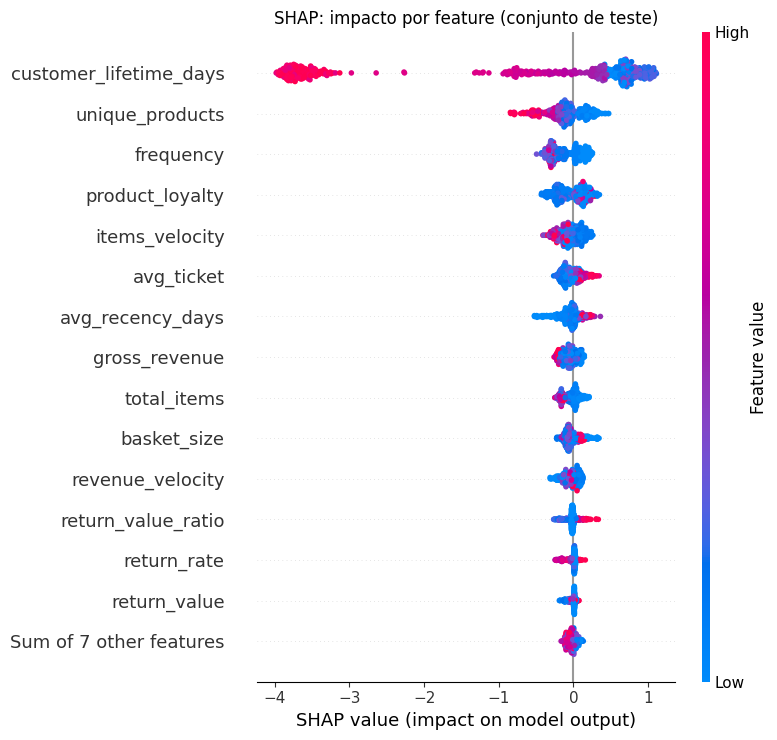

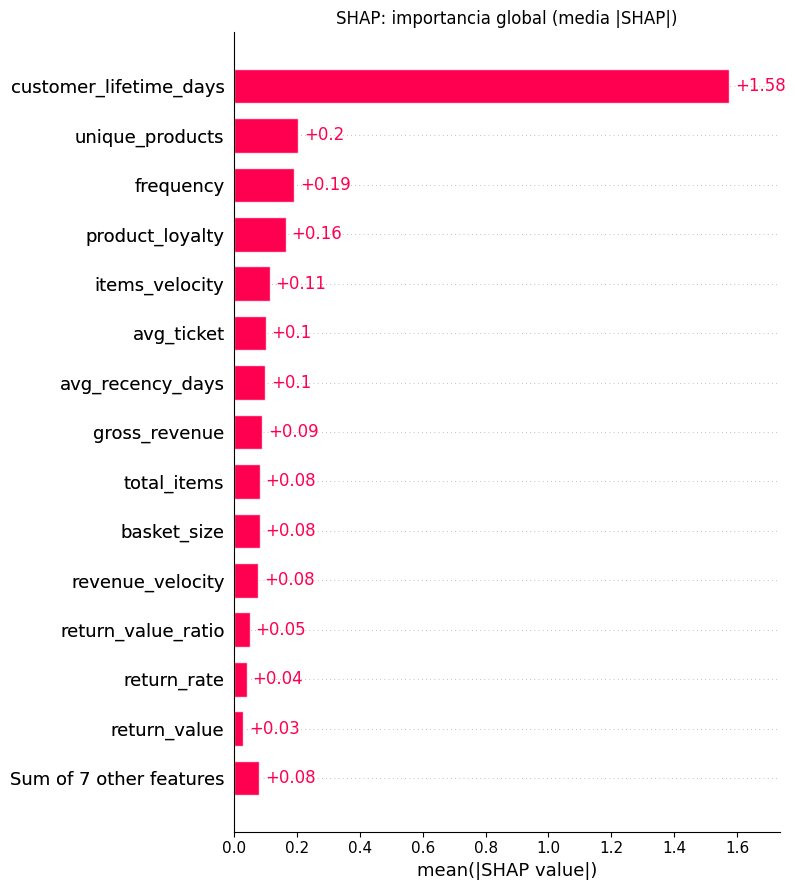

Top 8, media |SHAP|:
customer_lifetime_days    1.5754
unique_products           0.2041
frequency                 0.1903
product_loyalty           0.1638
items_velocity            0.1131
avg_ticket                0.1003
avg_recency_days          0.0985
gross_revenue             0.0885


In [3]:
shap.plots.beeswarm(explanation, max_display=15, show=False)
plt.title('SHAP: impacto por feature (conjunto de teste)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

shap.plots.bar(explanation, max_display=15, show=False)
plt.title('SHAP: importancia global (media |SHAP|)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_global_bar.png', dpi=150, bbox_inches='tight')
plt.show()

mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURES).sort_values(ascending=False)
print('Top 8, media |SHAP|:')
print(mean_abs_shap.head(8).round(4).to_string())

### 2.1. O efeito vai sempre no mesmo sentido? (`dependence plot`)

Na secao 4 a direcao de cada feature e resumida por uma correlacao linear entre o valor da
feature e o SHAP dela. Isso so e uma leitura honesta se o efeito for consistente, sempre na
mesma direcao. Se ele inverter (sobe e depois desce, formato de U ou corcova), a correlacao
linear fica perto de zero e engana. Abaixo, o `dependence plot` das duas features de maior
|SHAP| para conferir o formato.

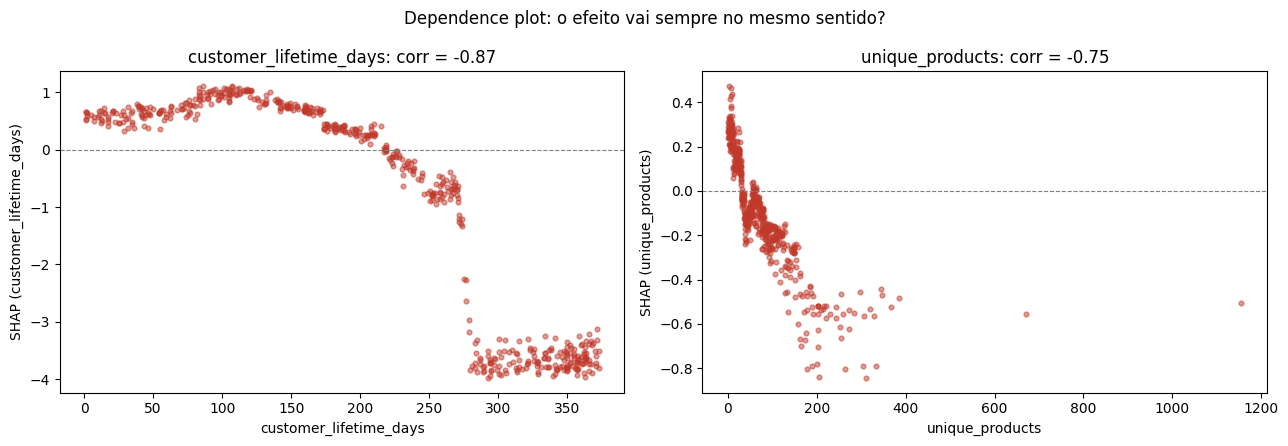

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, feat in zip(axes, mean_abs_shap.head(2).index):
    j = FEATURES.index(feat)
    corr = np.corrcoef(X_test[feat], shap_values[:, j])[0, 1]
    ax.scatter(X_test[feat].values, shap_values[:, j], s=12, alpha=0.5, color='#c0392b')
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlabel(feat)
    ax.set_ylabel(f'SHAP ({feat})')
    ax.set_title(f'{feat}: corr = {corr:+.2f}')
fig.suptitle('Dependence plot: o efeito vai sempre no mesmo sentido?')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

**Leitura dos dependence plots:**

- **`unique_products`**: decrescente com **saturacao**. Quanto mais produtos distintos, menor a
  contribuicao para churn, com retorno decrescente acima de cerca de 200. A correlacao linear
  (-0,75) descreve bem o efeito.
- **`customer_lifetime_days`**: **nao vai sempre no mesmo sentido**. Duas regioes:
  - ate cerca de 130 dias: contribuicao *positiva* (empurra para churn), com pico de risco entre
    80 e 130 dias, cliente novo que ja comprou 2 vezes mas ainda nao firmou habito.
  - acima disso: cai, cruza zero por volta de 215 dias, e tem um **degrau acentuado em cerca de
    270 dias** para forte protecao (SHAP proximo de -3,8), quase uma regra "lifetime > 270,
    cliente seguro".

  A correlacao de -0,87 captura a tendencia geral de queda, mas **esconde o degrau**. O resumo
  "valor maior, menos churn" (secao 4) vale como primeira aproximacao; o efeito real e uma
  quebra quase binaria em torno dos 270 dias.

## 3. Consistencia com a `feature_importances_` (gain) do notebook 02

Se os dois metodos concordam no essencial, e evidencia de que o modelo e estavel e o grafico do
notebook 02 nao estava enganando. Divergencias sao esperadas nas features de baixa relevancia:
**gain** mede a melhora media quando a feature e usada num split; **|SHAP|** mede a magnitude
media da contribuicao para as predicoes reais. Sao coisas diferentes.

Nao e uma comparacao: `|SHAP|` aqui e calculado no **conjunto de teste**, e o
`gain` (`feature_importances_`) vem do **treino** de cada fold. Esperamos concordancia
aproximada de ranking, nao `rho = 1`.

Spearman (ranking |SHAP| x ranking gain): rho = 0.744  (p = 1.1e-04)
Top 5 |SHAP|: ['customer_lifetime_days', 'unique_products', 'frequency', 'product_loyalty', 'items_velocity']
Top 5 gain : ['customer_lifetime_days', 'frequency', 'log_total_items', 'unique_products', 'avg_recency_days']


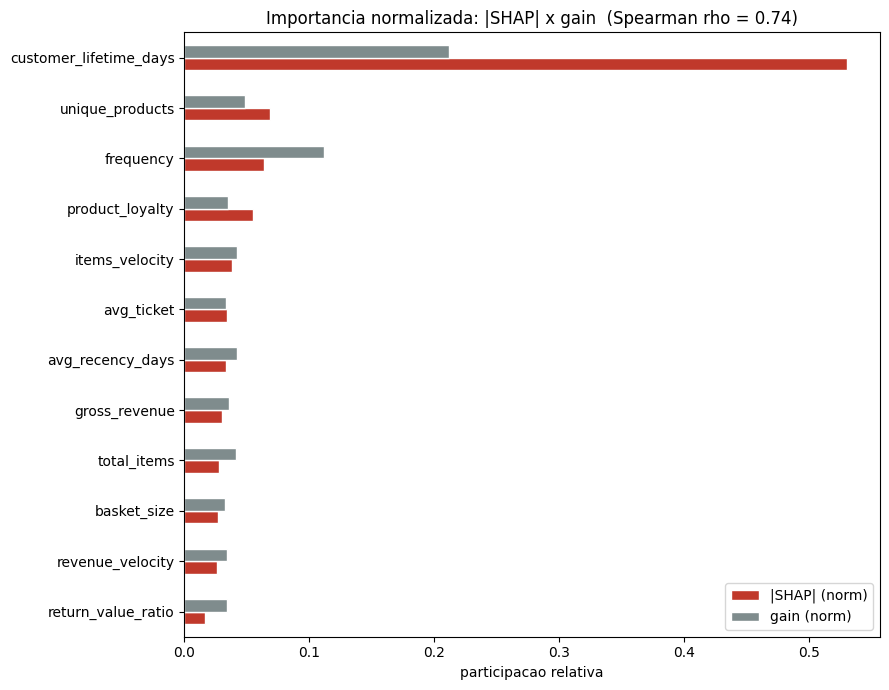

In [5]:
gain = pd.Series(
    np.mean([est.feature_importances_ for est in fold_estimators], axis=0),
    index=FEATURES,
).sort_values(ascending=False)

rho, p = spearmanr(
    mean_abs_shap.rank(ascending=False).reindex(FEATURES),
    gain.rank(ascending=False).reindex(FEATURES),
)
print(f'Spearman (ranking |SHAP| x ranking gain): rho = {rho:.3f}  (p = {p:.1e})')
print(f'Top 5 |SHAP|: {list(mean_abs_shap.head(5).index)}')
print(f'Top 5 gain : {list(gain.head(5).index)}')

comp = pd.DataFrame({
    '|SHAP| (norm)': (mean_abs_shap / mean_abs_shap.sum()),
    'gain (norm)': (gain / gain.sum()),
}).loc[mean_abs_shap.head(12).index].iloc[::-1]

ax = comp.plot(kind='barh', figsize=(9, 7), color=['#c0392b', '#7f8c8d'], edgecolor='white')
ax.set_title(f'Importancia normalizada: |SHAP| x gain  (Spearman rho = {rho:.2f})')
ax.set_xlabel('participacao relativa')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_vs_gain.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Sanidade de dominio

Para cada top feature, a direcao do efeito precisa fazer sentido para churn de e-commerce B2C.
Medindo a correlacao entre o valor da feature e a contribuicao SHAP dela: positiva significa
"valor maior empurra para churn", negativa significa "valor maior protege do churn".

> Vazamento obvio ja foi tratado `recency_days` (dias desde a ultima compra, que
> praticamente define o rotulo de churn de 90 dias) foi **excluido**.

In [6]:
rows = []
for f in mean_abs_shap.head(10).index:
    j = FEATURES.index(f)
    corr = np.corrcoef(X_test[f].values, shap_values[:, j])[0, 1]
    rows.append({
        'feature': f,
        'media_|SHAP|': round(mean_abs_shap[f], 4),
        'corr(valor, SHAP)': round(corr, 2),
        'direcao': 'valor MAIOR -> mais churn' if corr > 0 else 'valor MAIOR -> menos churn',
    })
print(pd.DataFrame(rows).to_string(index=False))

               feature  media_|SHAP|  corr(valor, SHAP)                    direcao
customer_lifetime_days        1.5754              -0.87 valor MAIOR -> menos churn
       unique_products        0.2041              -0.75 valor MAIOR -> menos churn
             frequency        0.1903              -0.44 valor MAIOR -> menos churn
       product_loyalty        0.1638               0.16  valor MAIOR -> mais churn
        items_velocity        0.1131              -0.16 valor MAIOR -> menos churn
            avg_ticket        0.1003               0.57  valor MAIOR -> mais churn
      avg_recency_days        0.0985               0.42  valor MAIOR -> mais churn
         gross_revenue        0.0885              -0.21 valor MAIOR -> menos churn
           total_items        0.0813              -0.19 valor MAIOR -> menos churn
           basket_size        0.0809               0.22  valor MAIOR -> mais churn


**Leitura das direcoes (top features por |SHAP|):**

- **`customer_lifetime_days`** (-0,87): relacionamento longo protege. Efeito dominante e o mais
  intuitivo.
- **`unique_products`** (-0,75): quem compra variedade explora o catalogo e fica. Sinal forte de
  engajamento.
- **`frequency`** (-0,44): mais pedidos ao longo do tempo, menos churn. Direto.
- **`items_velocity`** (-0,16): ritmo de itens comprados por periodo; mais ritmo, menos churn.
  Efeito fraco.
- **`avg_ticket`** (+0,57): ticket medio alto empurra para churn. Perfil "compra grande e
  esporadica": gasta muito de uma vez e some, diferente do recorrente de ticket menor.
- **`avg_recency_days`** (+0,42): intervalo medio maior entre compras e sinal de afastamento
  gradual. `recency_days` (dias desde a ultima compra, que define o rotulo) foi removido; este e
  a media dos gaps, comportamental, nao vazamento.
- **`product_loyalty`** (+0,16): razao `total_items / unique_products`, unidades medias compradas
  por produto distinto. Alto significa compra concentrada em poucos produtos; baixo significa
  cesta variada. Direcao coerente com `unique_products`: compra concentrada significa menos
  exploracao de catalogo, e e a exploracao que segura o cliente. Distribuicao bem assimetrica
  (mediana 13, max 8.000), entao o efeito fraco provavelmente vem de poucos clientes de volume
  atipico.

Todas as direcoes sao compativeis com churn de e-commerce B2C. Nada no topo que seja artefato de
dado.

## 5. Explicacao individual (`waterfall`)

Tres clientes do conjunto de teste:

- **Alto risco**: maior score entre quem realmente deu churn
- **Baixo risco**: menor score entre quem permaneceu ativo
- **Fronteira**: score mais proximo do threshold operacional de 0.20

O `waterfall` parte do *base value* (margem media) e soma as contribuicoes ate a margem do
cliente. Lembrar: a margem nao e o `P(churn)` mostrado ao negocio; a calibracao `sigmoid` por
cima so preserva a ordem, entao a direcao e a mesma.

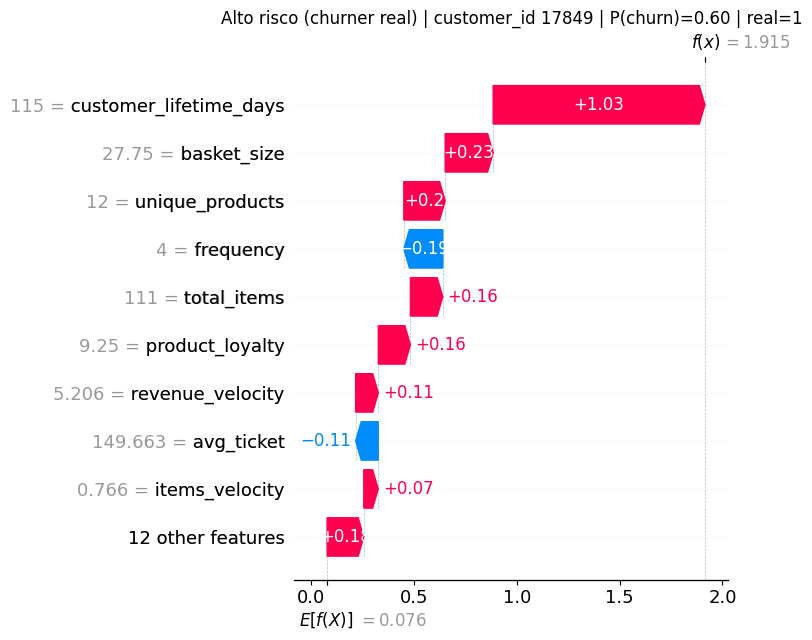


Alto risco (churner real) | customer_id 17849 | P(churn)=0.60 | real=1
  customer_lifetime_days   SHAP +1.030   (valor = 115.00)
  basket_size              SHAP +0.234   (valor = 27.75)
  unique_products          SHAP +0.201   (valor = 12.00)
  frequency                SHAP -0.190   (valor = 4.00)
  total_items              SHAP +0.158   (valor = 111.00)


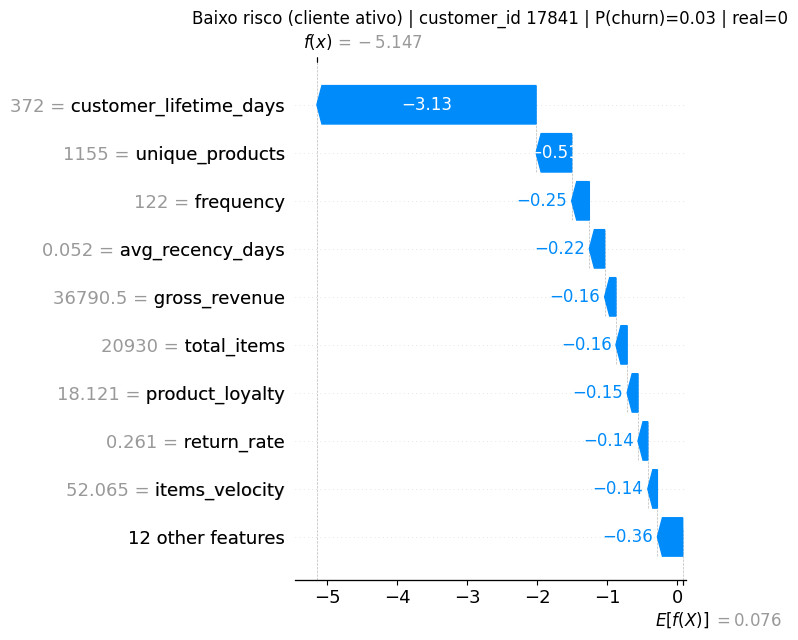


Baixo risco (cliente ativo) | customer_id 17841 | P(churn)=0.03 | real=0
  customer_lifetime_days   SHAP -3.130   (valor = 372.00)
  unique_products          SHAP -0.508   (valor = 1155.00)
  frequency                SHAP -0.252   (valor = 122.00)
  avg_recency_days         SHAP -0.218   (valor = 0.05)
  gross_revenue            SHAP -0.161   (valor = 36790.50)


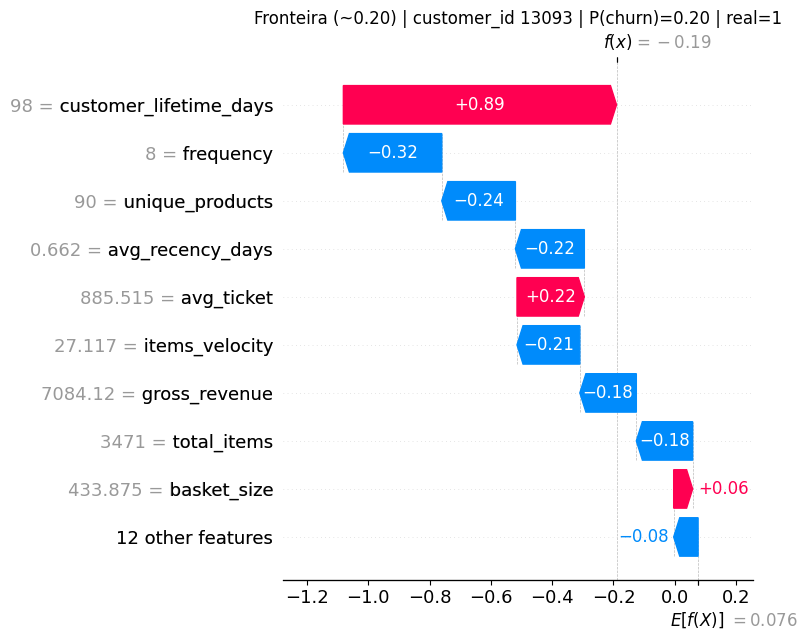


Fronteira (~0.20) | customer_id 13093 | P(churn)=0.20 | real=1
  customer_lifetime_days   SHAP +0.891   (valor = 98.00)
  frequency                SHAP -0.321   (valor = 8.00)
  unique_products          SHAP -0.240   (valor = 90.00)
  avg_recency_days         SHAP -0.225   (valor = 0.66)
  avg_ticket               SHAP +0.220   (valor = 885.51)


In [7]:
test_scores = churn_scores[churn_scores.split == 'test'].set_index('customer_id')
cid_high = test_scores[test_scores.churn_real == 1]['churn_score'].idxmax()
cid_low = test_scores[test_scores.churn_real == 0]['churn_score'].idxmin()
cid_border = (test_scores['churn_score'] - 0.20).abs().idxmin()

casos = [
    ('high', cid_high, 'Alto risco (churner real)'),
    ('low', cid_low, 'Baixo risco (cliente ativo)'),
    ('borderline', cid_border, 'Fronteira (~0.20)'),
]

for tag, cid, titulo in casos:
    pos = X_test.index.get_loc(cid)
    score = test_scores.loc[cid, 'churn_score']
    real = int(test_scores.loc[cid, 'churn_real'])
    shap.plots.waterfall(explanation[pos], max_display=10, show=False)
    plt.title(f'{titulo} | customer_id {cid} | P(churn)={score:.2f} | real={real}')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'shap_waterfall_{tag}.png', dpi=150, bbox_inches='tight')
    plt.show()

    contrib = pd.Series(shap_values[pos], index=FEATURES).sort_values(key=np.abs, ascending=False)
    print(f'\n{titulo} | customer_id {cid} | P(churn)={score:.2f} | real={real}')
    for f, v in contrib.head(5).items():
        print(f'  {f:<24} SHAP {v:+.3f}   (valor = {X_test.loc[cid, f]:.2f})')

## 6. Conclusao

**Consistencia.** Ranking |SHAP| e ranking gain concordam no essencial (Spearman por volta de
0,74): `customer_lifetime_days` e a feature dominante nos dois, seguida por `unique_products`,
`frequency` e `product_loyalty`. As divergencias ficam nas features de baixa relevancia (as
`log_*`), onde gain e |SHAP| naturalmente discordam. O grafico de importancia do notebook 02 nao
estava enganando.

**Sanidade de dominio.** Todas as direcoes das top features sao compativeis com churn B2C: 
tenure, variedade de produtos e frequencia protegem; intervalo entre compras e ticket medio 
alto puxam para churn. Nada no topo que seja artefato de dado.

**Ressalva para monitoramento em producao.** `customer_lifetime_days` concentra a maior parte da
contribuicao do modelo (media |SHAP| por volta de 8 vezes a segunda feature), e o efeito nao e
suave: o dependence plot (secao 2.1) mostra um degrau em torno de 270 dias. O modelo e robusto
hoje, mas essa dependencia quase binaria de uma unica feature e um ponto de atencao: se a
distribuicao dela deslocar em torno desse ponto (mudanca na base de clientes, na definicao de
"lifetime" no pipeline), o comportamento do modelo muda de forma abrupta. Sugestao: acompanhar
PSI dessa feature e re-treinar quando o desvio passar de um limiar.

**Uso pelo negocio.** O `waterfall` entrega ao time de retencao a justificativa por cliente
("entrou na lista porque `customer_lifetime_days` baixo e `frequency` baixa").